# Cosine Similarity

### Import/load stuff

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_distances

MISSING_LABEL = "Non-typeable"
MIN_COUNT = 2 

EMBEDDINGS_PATH = "/Users/tajmirri/Documents/Workspace/data/gps/contrastive_embeddings.npy"
LABELS_PATH = "/Users/tajmirri/Documents/Workspace/data/gps/GPS_All_clean_labels.tsv"
OUT_PATH = "plot.pdf"


In [2]:
# Load embeddings
X = np.load(EMBEDDINGS_PATH)
labels = pd.read_csv(LABELS_PATH, sep="\t")
assert X.shape[0] == len(labels), "Number of embeddings and labels do not match."

labels['Serotype'] = labels['Serotype'].fillna(MISSING_LABEL)

# In case "someone" has messed up while cleaning the data
is_duplicate = labels.duplicated()
if is_duplicate.any():
    print("Dropping duplicate label rows...")
    labels, X = labels[~is_duplicate], X[~is_duplicate]

known_indices = labels['Serotype'] != MISSING_LABEL

# Drop samples with labels that only occur once
underrep_labels = labels['Serotype'].value_counts()[labels['Serotype'].value_counts() < MIN_COUNT].index
if underrep_labels.any():
    print(f"Dropping serotypes with less than {MIN_COUNT} samples:", *underrep_labels.to_list())
    known_indices &= ~labels['Serotype'].isin(underrep_labels)

X, labels = X[known_indices], labels[known_indices]["Serotype"].reset_index(drop=True)

Dropping duplicate label rows...
Dropping serotypes with less than 2 samples: 32 35B/35D 10C 25A 33A/33F 41F 32F


## Everything against everything

### Construct

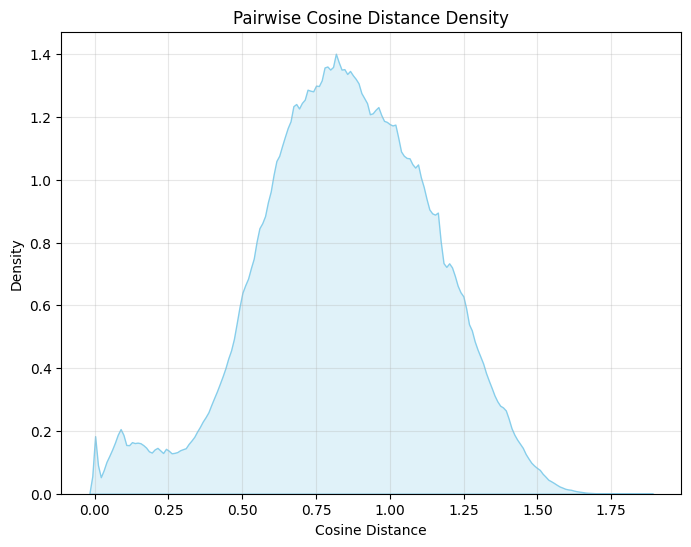

<Figure size 640x480 with 0 Axes>

In [ ]:
dist_path = EMBEDDINGS_PATH.replace("contrastive_embeddings.npy", "pairwise_distances.csv")
if not os.path.exists(dist_path):
    print("Computing pairwise distances...")
    dist_matrix = cosine_distances(X, X)
    pairwise_distances = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]
    print(f"Saving pairwise distances to {dist_path}...")
    np.savez(dist_path, distances=pairwise_distances, size=dist_matrix.shape[0])
else:
    print("Loading pairwise distances...")
    dist_data = np.load(dist_path)
    pairwise_distances = dist_data['distances']
    dist_matrix = np.zeros((dist_data['size'], dist_data['size']))
    dist_matrix[np.triu_indices_from(dist_matrix, k=1)] = pairwise_distances
    dist_matrix += dist_matrix.T
    np.fill_diagonal(dist_matrix, 0)
# Compute cosine distances (efficiently, using all available threads)
dist_matrix = cosine_distances(X, X)

# Plot the density
plt.figure(figsize=(8, 6))
sns.kdeplot(pairwise_distances, fill=True, color='skyblue')
plt.title('Pairwise Cosine Distance Density')
plt.xlabel('Cosine Distance')
plt.ylabel('Density')
plt.grid(alpha=0.3)

# Save the plot
plt.show()
plt.savefig(OUT_PATH)


### Or load:

In [3]:
print("Loading the distance matrix...")
dist_data = np.load("/Users/tajmirri/Documents/Workspace/Pneumococcal-Serotyping/1_data_annotation/results/distances.npz")
pairwise_distances = dist_data["distances"]
dist_matrix = np.zeros((dist_data["size"], dist_data["size"]))
dist_matrix[np.triu_indices_from(dist_matrix, k=1)] = dist_data["distances"]
dist_matrix += dist_matrix.T

Loading the distance matrix...


In [13]:
len(pairwise_distances)

614128581

### Fit GMM (2 components) + Cheating

GMM means: [[0.09254204]
 [0.77864743]]
GMM covariances: [[[0.00142507]]

 [[0.05490785]]]
GMM weights: [0.02164436 0.97835564]


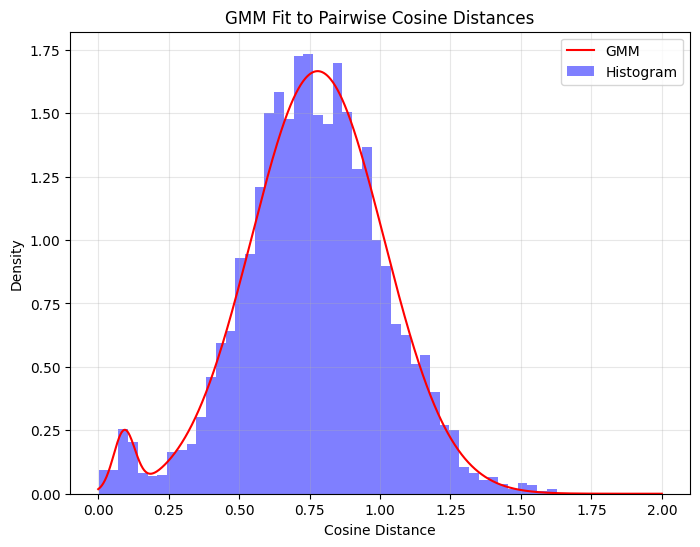

In [76]:
from sklearn.mixture import GaussianMixture
TOP = 100000
gmm = GaussianMixture(n_components=2, covariance_type='full', means_init=np.array([[0.08], [0.75]]), weights_init=np.array([0.1, 0.9]), precisions_init=None, random_state=0, n_init=30) 
gmm.fit(pairwise_distances[:TOP].reshape(-1, 1))
print("GMM means:", gmm.means_)
print("GMM covariances:", gmm.covariances_)
print("GMM weights:", gmm.weights_)
# Plot the GMM
x = np.linspace(0, 2, 1000)
y = np.exp(gmm.score_samples(x.reshape(-1, 1)))
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='GMM', color='red')
plt.hist(pairwise_distances[:TOP], bins=50, density=True, alpha=0.5, label='Histogram', color='blue')
plt.title('GMM Fit to Pairwise Cosine Distances')
plt.xlabel('Cosine Distance')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [78]:
norm.ppf(0.98, loc=gmm.means_[-1], scale=np.sqrt(gmm.covariances_[-1][0]))

array([1.25989056])

BGM means: [[0.7358749 ]
 [0.78494276]]
BGM covariances: [[[0.09540719]]

 [[0.03868307]]]
BGM weights: [0.43094563 0.56905437]


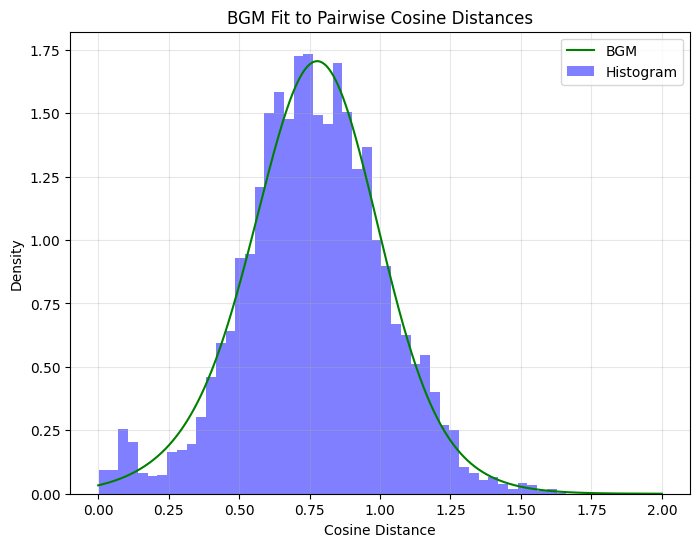

In [73]:
from sklearn.mixture import BayesianGaussianMixture
TOP = 100000
bgm = BayesianGaussianMixture(
    n_components=2,
    weight_concentration_prior_type='dirichlet_distribution',
    weight_concentration_prior=0.01,   # small → encourages uneven weights
    covariance_type='full',
    max_iter=1000,
    random_state=42
)
bgm.fit(pairwise_distances[:TOP].reshape(-1,1))
print("BGM means:", bgm.means_)
print("BGM covariances:", bgm.covariances_)
print("BGM weights:", bgm.weights_)
# Plot the BGM
x = np.linspace(0, 2, 1000)
y = np.exp(bgm.score_samples(x.reshape(-1, 1)))
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='BGM', color='green')
plt.hist(pairwise_distances[:TOP], bins=50, density=True, alpha=0.5, label='Histogram', color='blue')
plt.title('BGM Fit to Pairwise Cosine Distances')
plt.xlabel('Cosine Distance')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Fit 1 normal

Normal parameters: (np.float32(0.7637971), np.float32(0.25242344))


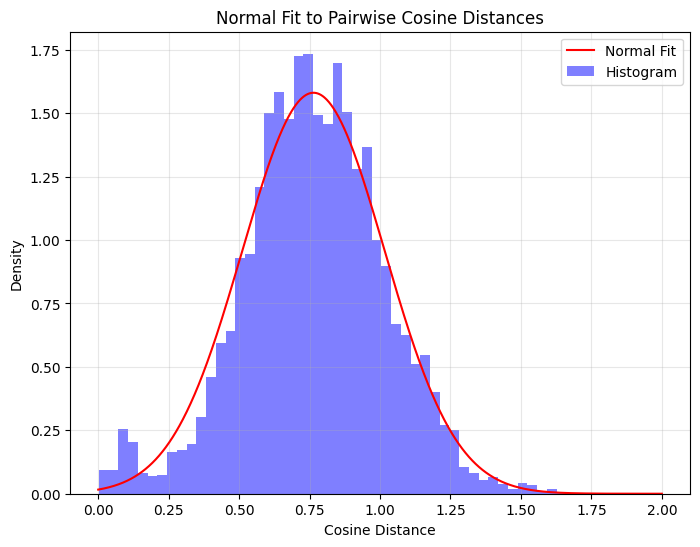

In [66]:
# do a norm.fit and plot the histogram
from scipy.stats import norm

normal_parameters = norm.fit(pairwise_distances[:TOP])
print("Normal parameters:", normal_parameters)
x = np.linspace(0, 2, 1000)
y = norm.pdf(x, *normal_parameters)
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='Normal Fit', color='red')
plt.hist(pairwise_distances[:TOP], bins=50, density=True, alpha=0.5, label='Histogram', color='blue')
plt.title('Normal Fit to Pairwise Cosine Distances')
plt.xlabel('Cosine Distance')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [68]:
norm.ppf(0.98, *normal_parameters)

np.float64(1.2822114599312318)

## Individual Serogroups

#### Mapping to sero(/geno)groups

In [51]:
SEROTYPE_GROUPS = {
    "6A": "6",
    "6B": "6",
    "6C": "6",
    "6D": "6",
    "6E(6B)": "6",
    "7B": "7B_7C_40",
    "7C": "7B_7C_40",
    "7F": "7A_7F",
    "9A": "9",
    "9L": "9",
    "9N": "9",
    "9V": "9",
    "10A": "10",
    "10B": "10",
    "10C": "10",
    "10F": "10",
    "10X": "33G",
    "11A": "11",
    "11B": "11",
    "11C": "11",
    "11E": "11",
    "12A": "12_44_46",
    "12B": "12_44_46",
    "12F": "12_44_46",
    "15A": "15",
    "15B": "15",
    "15C": "15",
    "15B/15C": "15",
    "15F": "15",
    "18A": "18",
    "18B": "18",
    "18C": "18",
    "18F": "18",
    "19A": "19A",
    "19B": "19B_19C",
    "19F": "19F",
    "20": "20",
    "20A": "20",
    "20B": "20",
    "22A": "22",
    "22F": "22",
    "23A": "23",
    "23B": "23",
    "23B1": "23",
    "23F": "23",
    "24": "24",
    "24A": "24",
    "24F": "24",
    "25A": "25A_25F_38",
    "25F": "25A_25F_38",
    "28A": "28",
    "28F": "28",
    "33A": "33A_33F_37",
    "33A/33F": "33A_33F_37",
    "33B": "33B_33D",
    "33D": "33B_33D",
    "33F": "33A_33F_37",
    "35A": "35A_35C_42",
    "35B": "35B_35D",
    "35B/35D": "35B_35D",
    "35C": "35A_35C_42",
    "35D": "35B_35D",
    "37": "33A_33F_37",
    "38": "25A_25F_38",
    "39X": "10D",
    "40": "7B_7C_40",
    "42": "35A_35C_42",
    "46": "12_44_46"
}


def map_serotype_to_group(serotype):
    """ Map serotype to a more coarse label by
    looking it up in the serogroup/genogroups data. """
    if isinstance(serotype, str):
        return SEROTYPE_GROUPS.get(serotype, serotype)
    print(f"Warning: {serotype} not found in mapping.")
    return serotype

group_labels = labels.map(map_serotype_to_group)
print("Serotype groups count:", len(group_labels.unique()))

Serotype groups count: 46


### Sero(/geno)groups + underlying distribution components (sorted by data abundance)
#### Top 25

7it [00:17,  1.74s/it]/var/folders/5v/j89g0bsx54vfv5d3s2w7v6pc0000gp/T/ipykernel_69927/3570580319.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=axes[i], alpha=0.5, label=sub_serotype, linestyle='dashed')  # , color='orange'
25it [00:24,  1.01it/s]


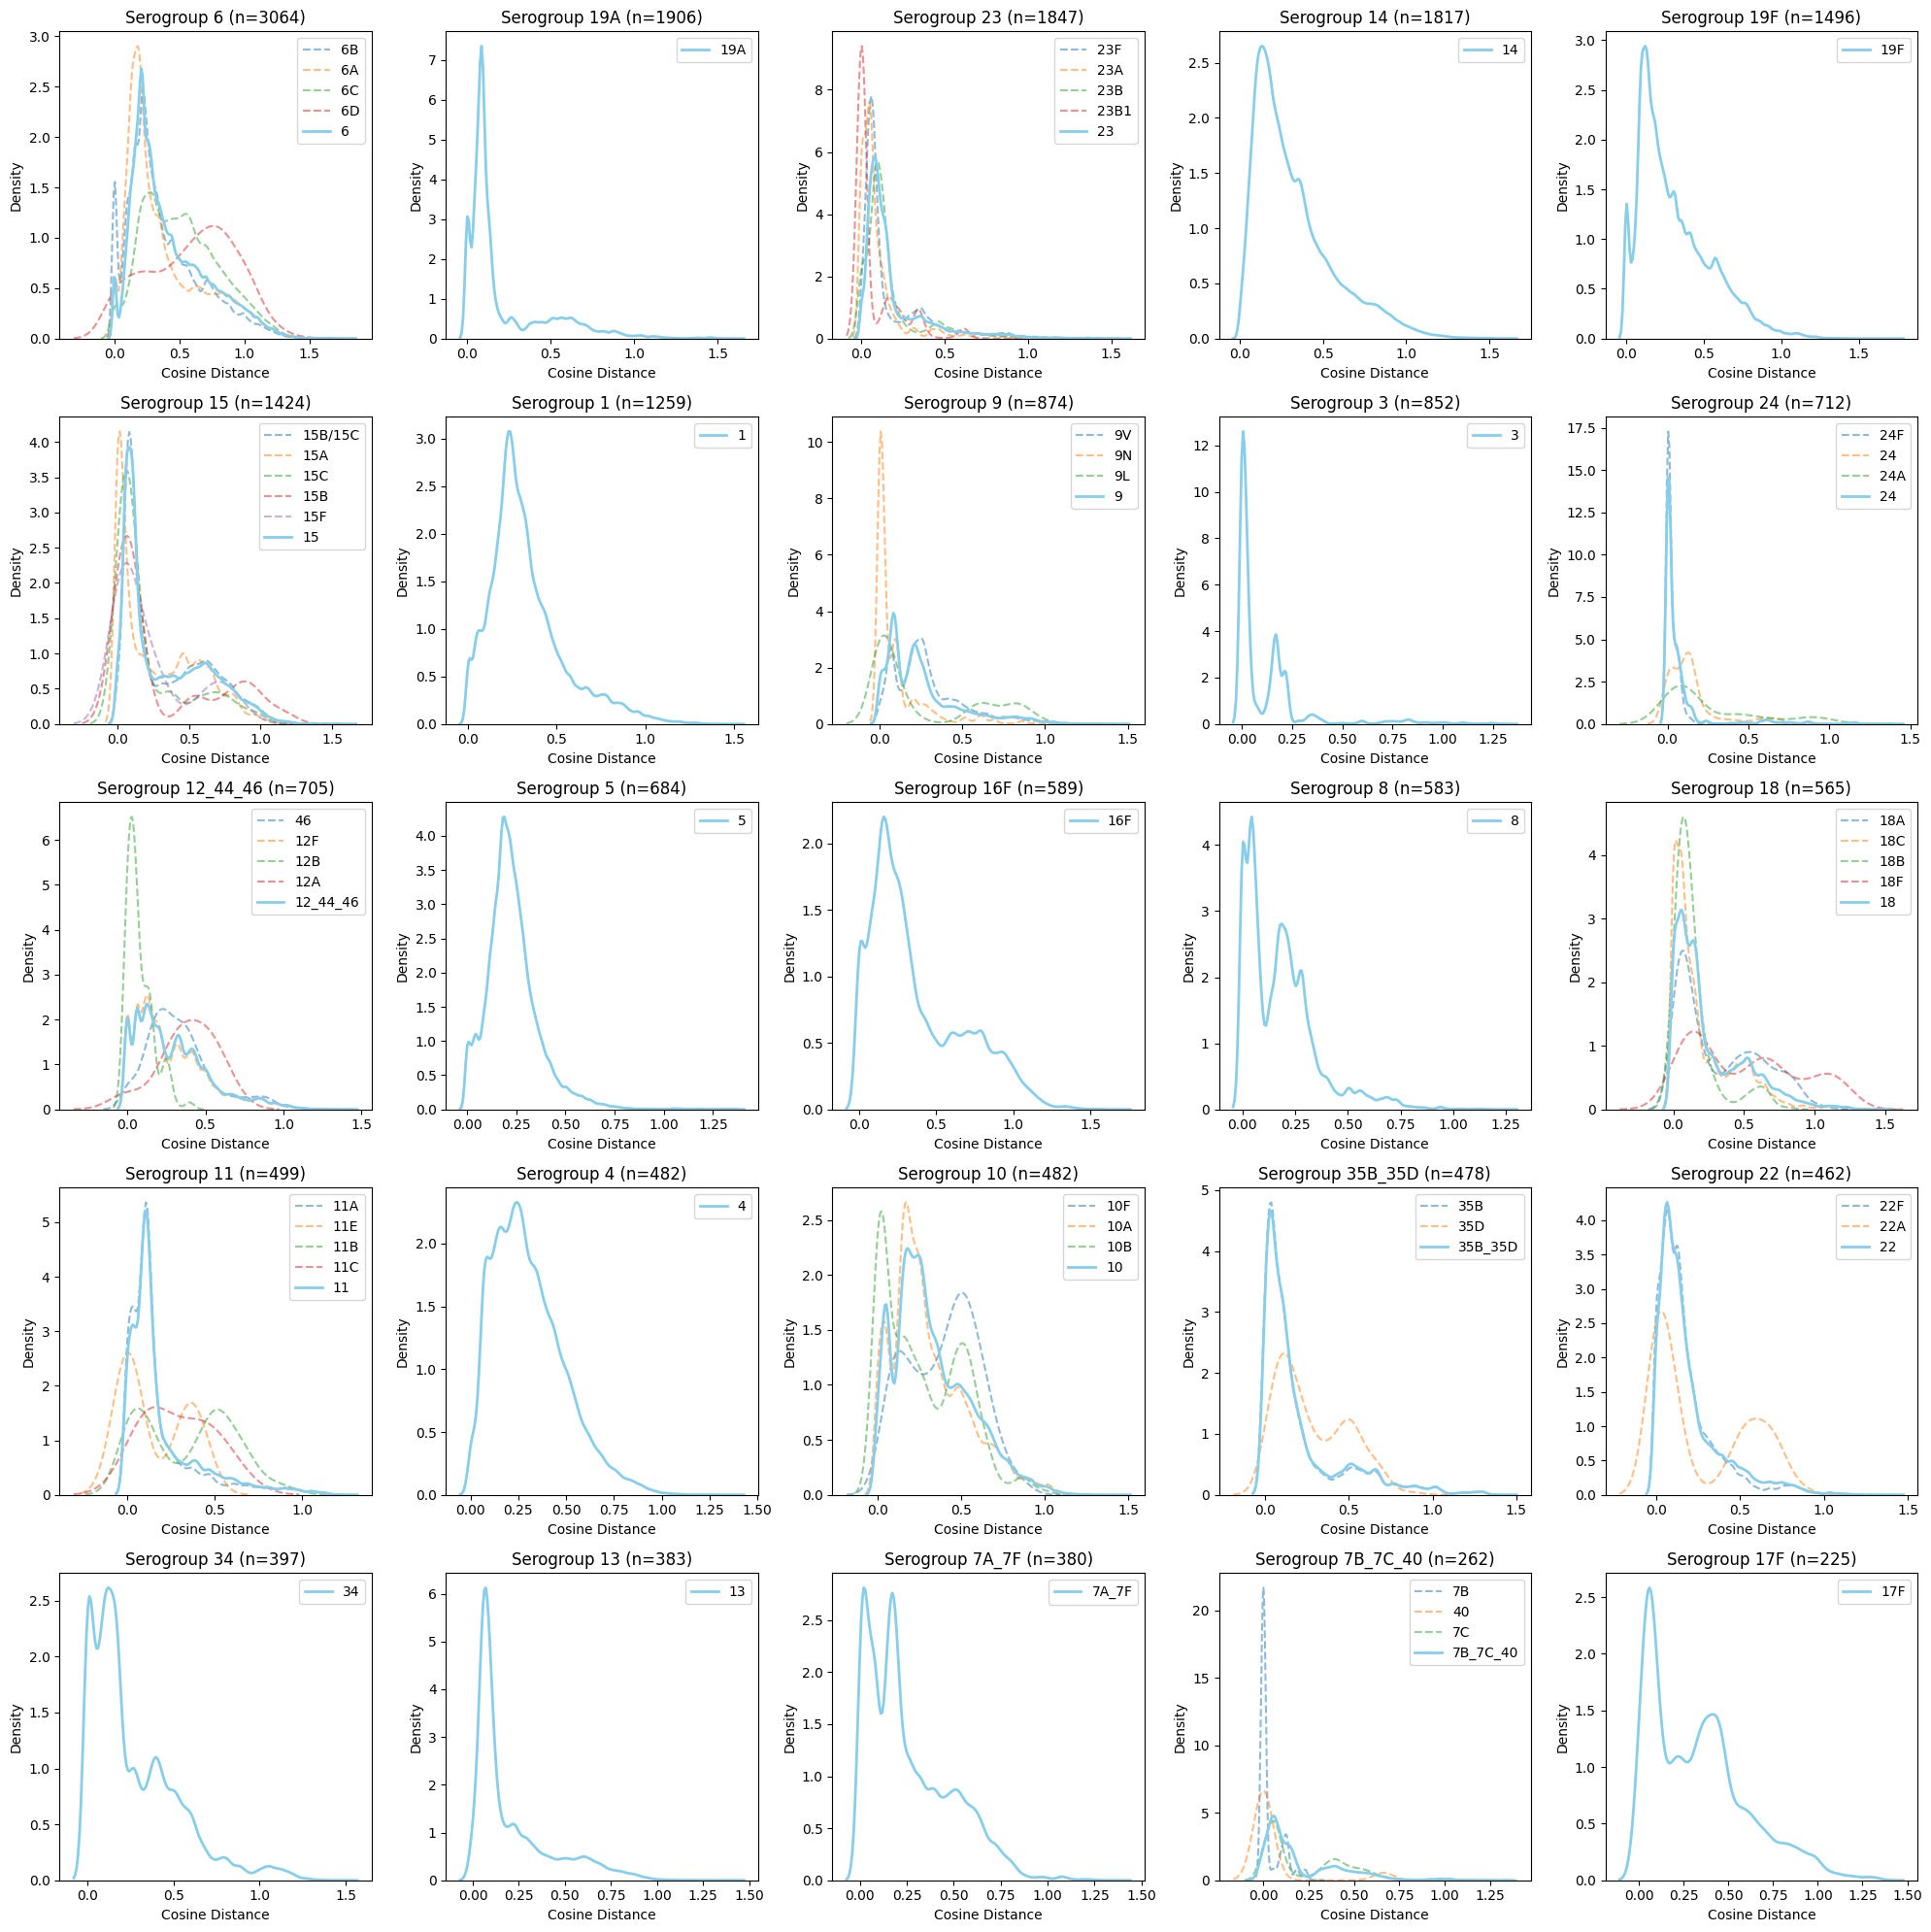

In [42]:
SHOW_TOP = 25
serotype_counts = group_labels.value_counts().sort_values(ascending=False)
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for i, (serogroup, count) in tqdm(enumerate(serotype_counts.items())):
    if i >= 25:  # Limit to the top 25 serotypes
        break

    # Filter X based on the current serotype
    # print(f"Processing serotype: {serotype} (n={count})")
    serotype_indices = group_labels[group_labels == serogroup].index
    submatrix = dist_matrix[serotype_indices][:, serotype_indices]
    pairwise_distances_serotype = submatrix[np.triu_indices_from(submatrix, k=1)]

    # plot the fine labels on top of the coarse labels
    sub_serotypes = labels[serotype_indices].unique()
    if len(sub_serotypes) > 1:
        # Create a new axis for the sub-serotypes
        for sub_serotype in sub_serotypes:
            sub_serotype_indices = labels[labels == sub_serotype].index
            submatrix = dist_matrix[sub_serotype_indices][:, sub_serotype_indices]
            pairwise_distances_subserotype = submatrix[np.triu_indices_from(submatrix, k=1)]
            sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=axes[i], alpha=0.5, label=sub_serotype, linestyle='dashed')  # , color='orange'
            # axes[i].legend(title="Sub-serotype", loc='upper right')

    # Plot the density
    ax = axes[i]
    sns.kdeplot(pairwise_distances_serotype, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=2)
    ax.legend(loc='upper right')
    ax.set_title(f"Serogroup {serogroup} (n={count})")
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Density')

# Adjust layout
plt.tight_layout()
plt.show()

#### Bottom 16

0it [00:00, ?it/s]/var/folders/5v/j89g0bsx54vfv5d3s2w7v6pc0000gp/T/ipykernel_69927/4196168223.py:22: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=ax, alpha=0.4, label=sub_serotype, color='orange', linestyle='dashed')
31it [00:00, 265.93it/s]/var/folders/5v/j89g0bsx54vfv5d3s2w7v6pc0000gp/T/ipykernel_69927/4196168223.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pairwise_distances_serotype, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=1.5)
/var/folders/5v/j89g0bsx54vfv5d3s2w7v6pc0000gp/T/ipykernel_69927/4196168223.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')
46it [00:00, 100.62it/s]


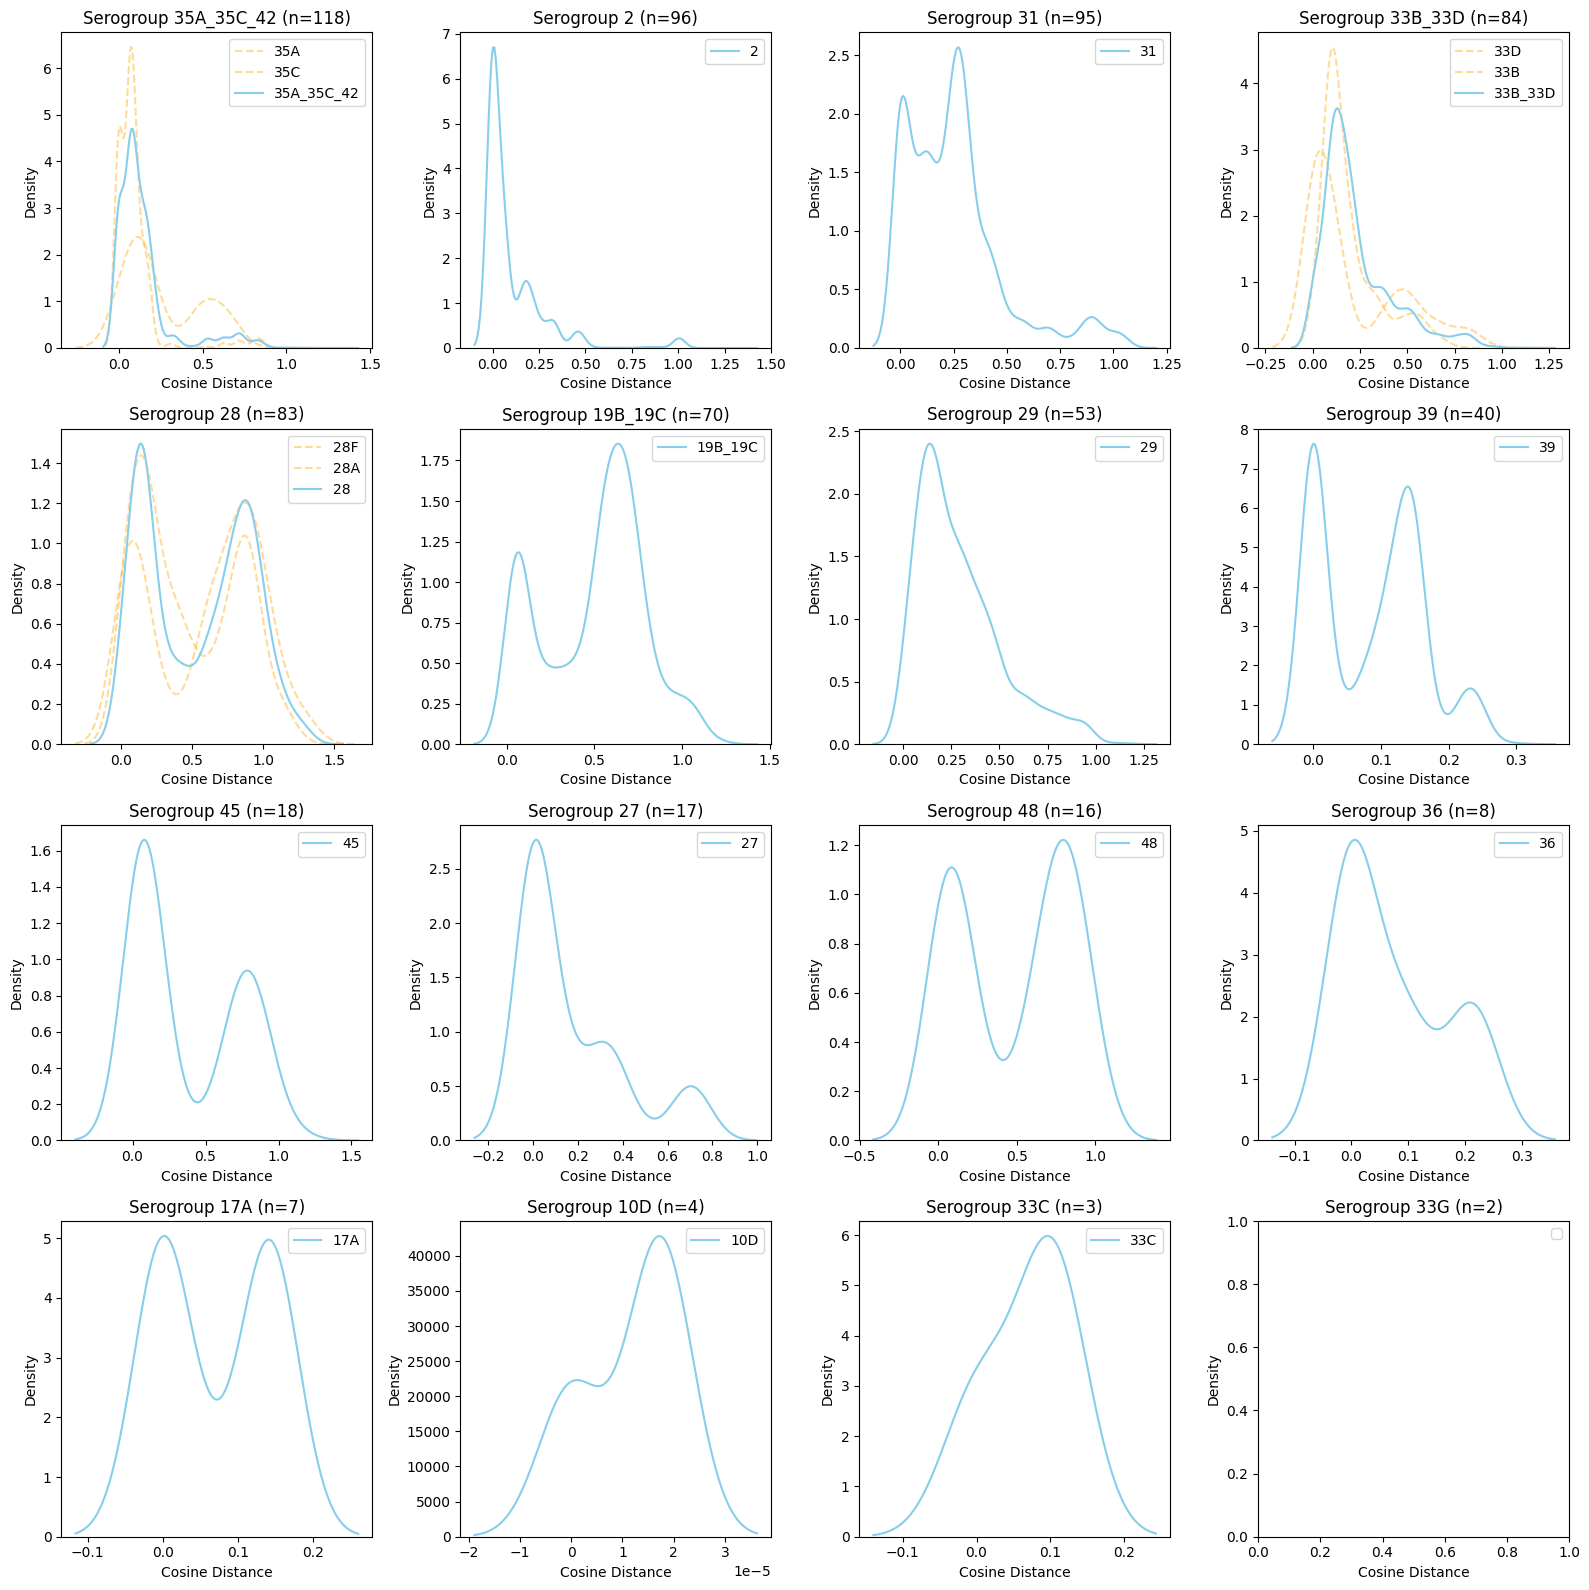

In [41]:
SHOW_BOTTOM = 16
serotype_counts = group_labels.value_counts().sort_values(ascending=False)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, (serogroup, count) in tqdm(enumerate(serotype_counts.items())):
    if i < 30:  # Skip the top serotypes
        continue
    ax = axes[i - 30]
    serotype_indices = group_labels[group_labels == serogroup].index
    submatrix = dist_matrix[serotype_indices][:, serotype_indices]
    pairwise_distances_serotype = submatrix[np.triu_indices_from(submatrix, k=1)]

    # plot the fine labels on top of the coarse labels
    sub_serotypes = labels[serotype_indices].unique()
    if len(sub_serotypes) > 1:
        # Create a new axis for the sub-serotypes
        for sub_serotype in sub_serotypes:
            sub_serotype_indices = labels[labels == sub_serotype].index
            submatrix = dist_matrix[sub_serotype_indices][:, sub_serotype_indices]
            pairwise_distances_subserotype = submatrix[np.triu_indices_from(submatrix, k=1)]
            sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=ax, alpha=0.4, label=sub_serotype, color='orange', linestyle='dashed')
            # axes[i].legend(title="Sub-serotype", loc='upper right')

    # Plot the density
    sns.kdeplot(pairwise_distances_serotype, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=1.5)
    ax.legend(loc='upper right')
    ax.set_title(f"Serogroup {serogroup} (n={count})")
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Density')

# Adjust layout
plt.tight_layout()
plt.show()

## One vs. All

25it [13:00, 31.21s/it]


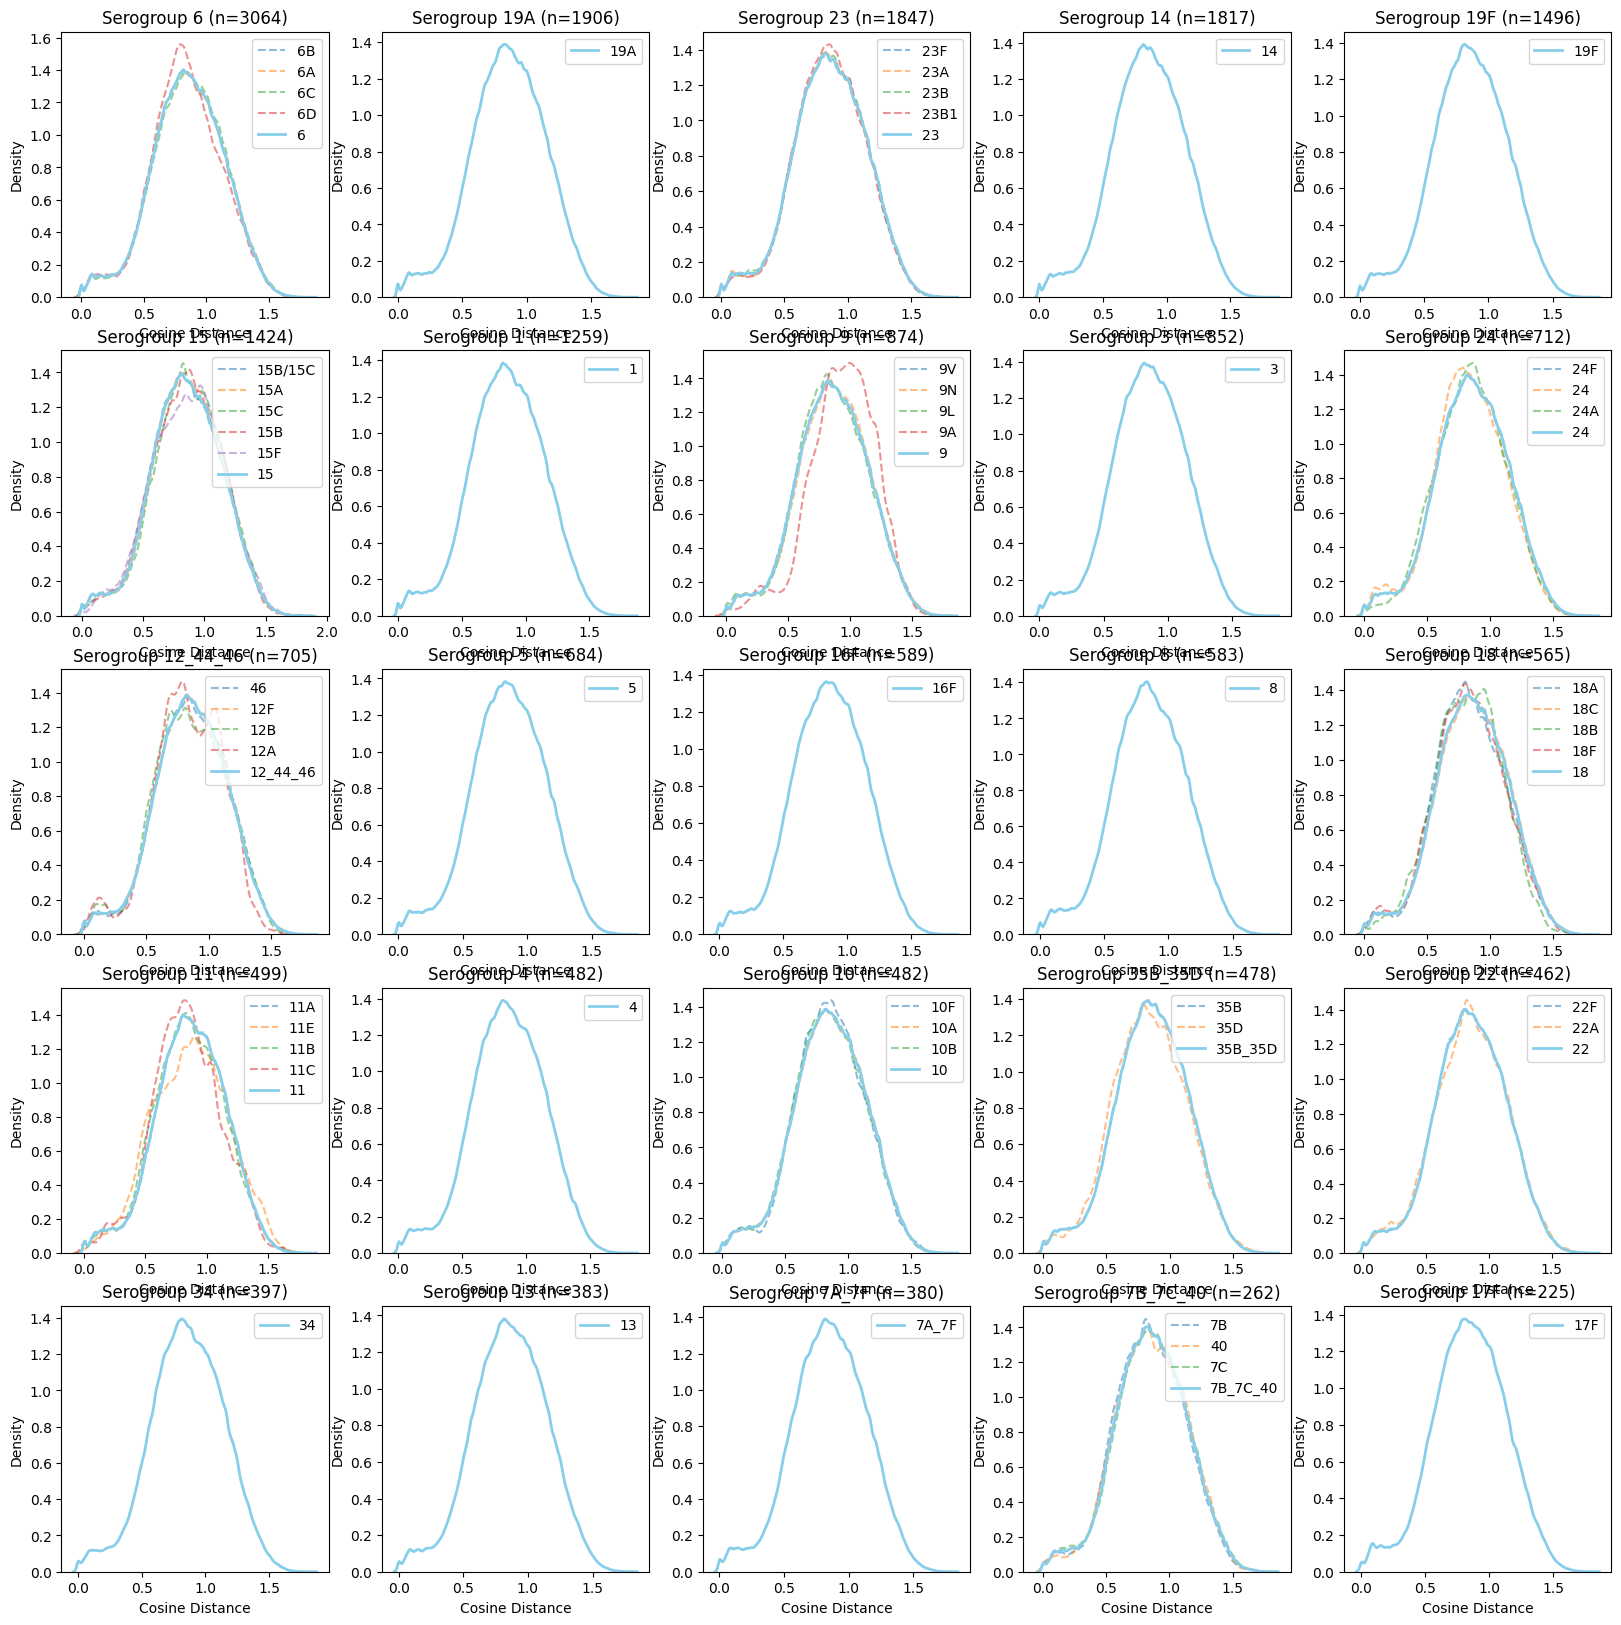

In [ ]:
# now plot every serogroup against the rest
serotype_counts = group_labels.value_counts().sort_values(ascending=False)
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for i, (serogroup, count) in tqdm(enumerate(serotype_counts.items())):
    if i >= 25:  # Limit to the top 25 serotypes
        break

    # Filter X based on the current serotype
    # print(f"Processing serotype: {serotype} (n={count})")
    serotype_indices = group_labels[group_labels == serogroup].index
    rest_indices = group_labels[group_labels != serogroup].index
    submatrix = dist_matrix[serotype_indices][:, rest_indices]
    pairwise_distances_serotype = submatrix[np.triu_indices_from(submatrix, k=1)]

    # plot the fine labels on top of the coarse labels
    sub_serotypes = labels[serotype_indices].unique()
    if len(sub_serotypes) > 1:
        # Create a new axis for the sub-serotypes
        for sub_serotype in sub_serotypes:
            sub_serotype_indices = labels[labels == sub_serotype].index
            submatrix = dist_matrix[sub_serotype_indices][:, rest_indices]
            pairwise_distances_subserotype = submatrix[np.triu_indices_from(submatrix, k=1)]
            sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=axes[i], alpha=0.5, label=sub_serotype, linestyle='dashed')  # , color='orange'
            # axes[i].legend(title="Sub-serotype", loc='upper right')

    # Plot the density
    ax = axes[i]
    sns.kdeplot(pairwise_distances_serotype, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=2)
    ax.legend(loc='upper right')
    ax.set_title(f"Serogroup {serogroup} (n={count})")
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

46it [00:28,  1.62it/s]


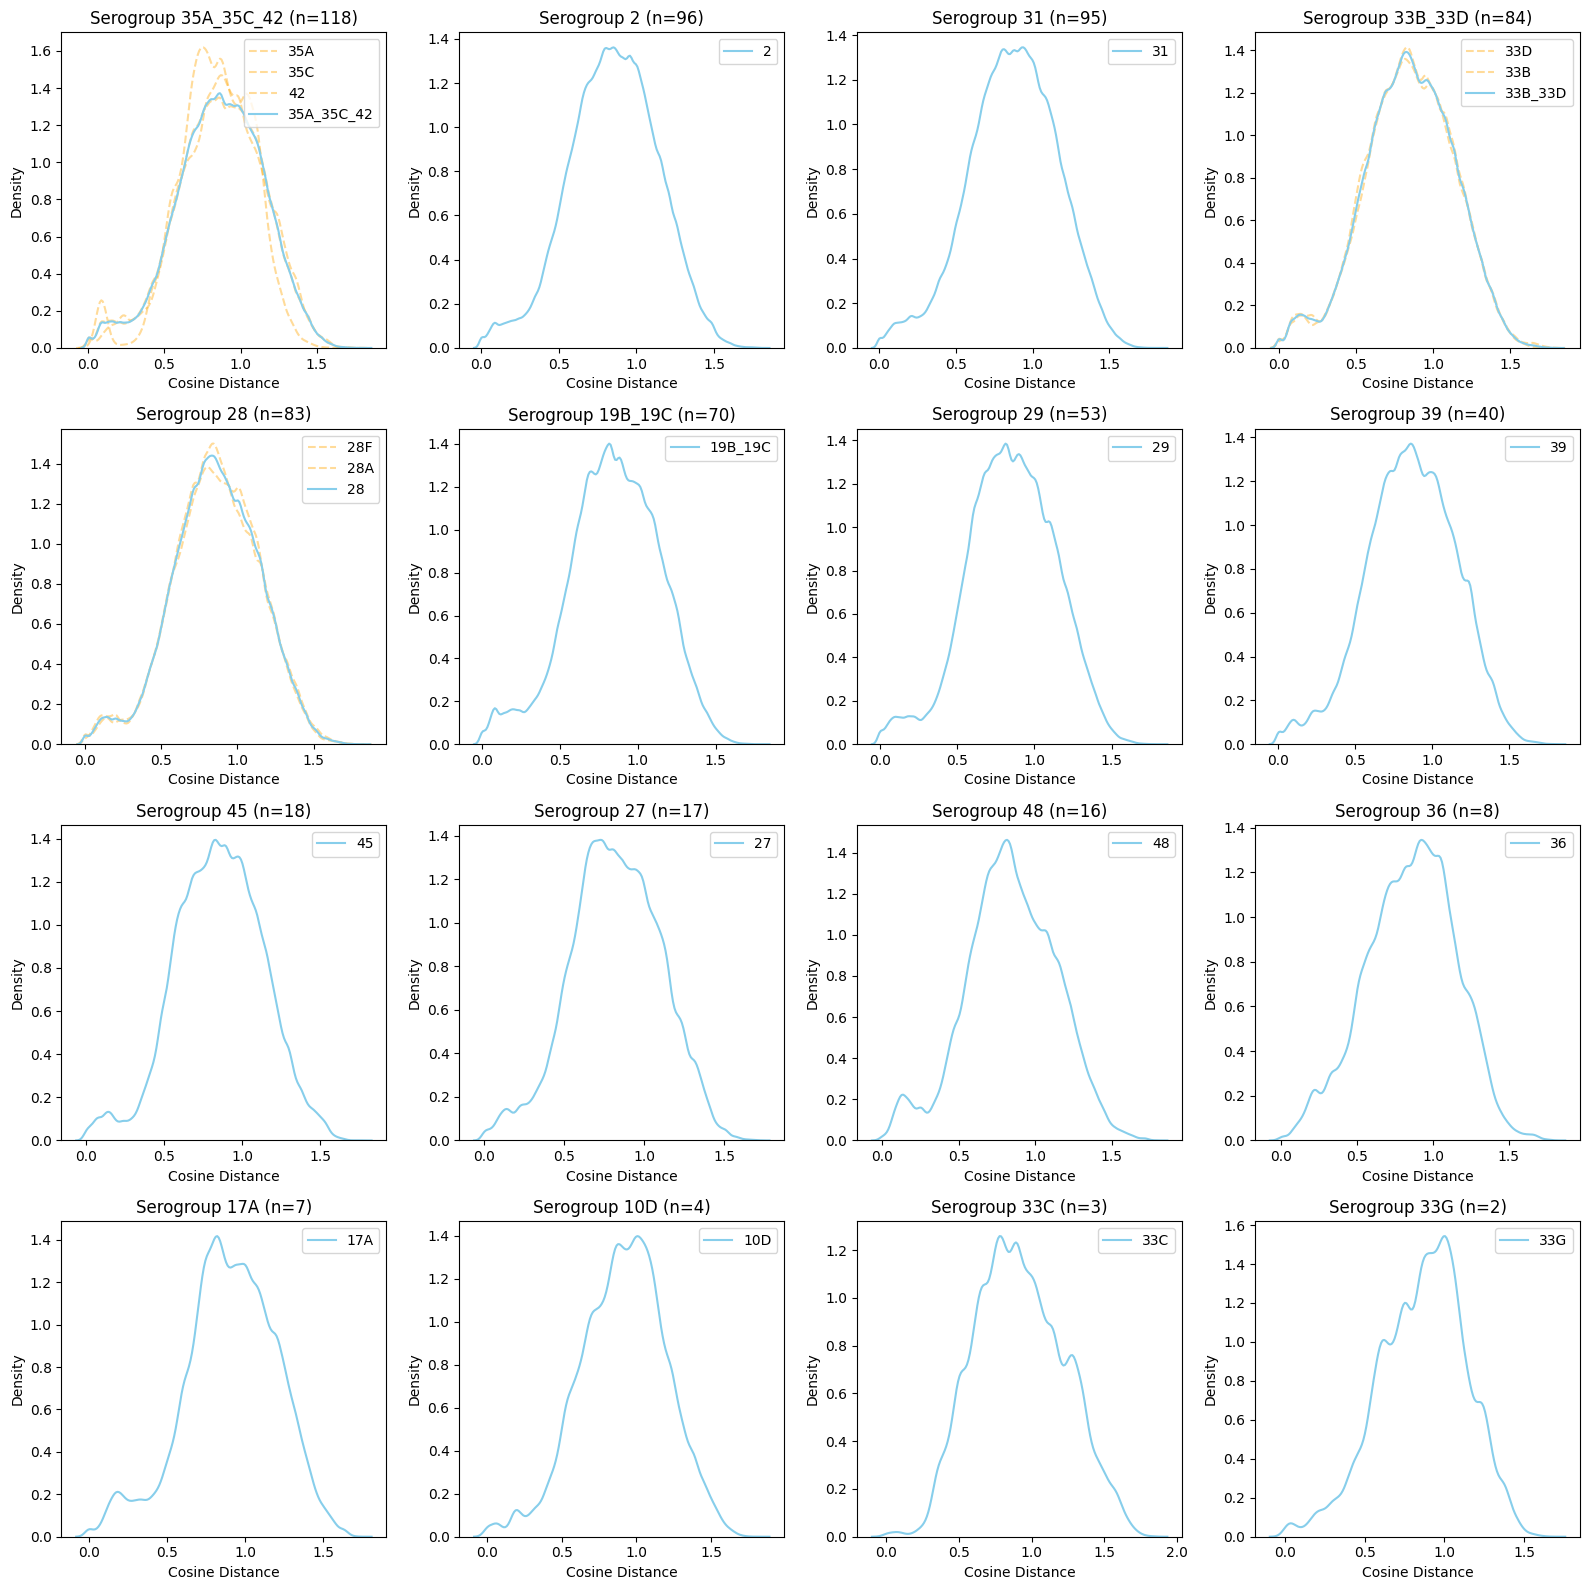

In [69]:
# now,again, the bottom 16 serogroups
SHOW_BOTTOM = 16
serotype_counts = group_labels.value_counts().sort_values(ascending=False)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, (serogroup, count) in tqdm(enumerate(serotype_counts.items())):
    if i < 30:  # Skip the top serotypes
        continue
    ax = axes[i - 30]
    serotype_indices = group_labels[group_labels == serogroup].index
    rest_indices = group_labels[group_labels != serogroup].index
    submatrix = dist_matrix[serotype_indices][:, rest_indices]
    pairwise_distances_serotype = submatrix[np.triu_indices_from(submatrix, k=1)]

    # plot the fine labels on top of the coarse labels
    sub_serotypes = labels[serotype_indices].unique()
    if len(sub_serotypes) > 1:
        # Create a new axis for the sub-serotypes
        for sub_serotype in sub_serotypes:
            sub_serotype_indices = labels[labels == sub_serotype].index
            submatrix = dist_matrix[sub_serotype_indices][:, rest_indices]
            pairwise_distances_subserotype = submatrix[np.triu_indices_from(submatrix, k=1)]
            sns.kdeplot(pairwise_distances_subserotype, fill=False, ax=ax, alpha=0.4, label=sub_serotype, color='orange', linestyle='dashed')
            # axes[i].legend(title="Sub-serotype", loc='upper right')

    # Plot the density
    sns.kdeplot(pairwise_distances_serotype, fill=False, color='skyblue', ax=ax, label=serogroup, linewidth=1.5)
    ax.legend(loc='upper right')
    ax.set_title(f"Serogroup {serogroup} (n={count})")
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Density')
# Adjust layout
plt.tight_layout()
plt.show()
